# Paper figures (draft): global vs input-only init scaling

This notebook mirrors the paper-draft plotting style, but compares **initialization scope**:
- `global` scaling (legacy behavior; scales all trainable parameters)
- `input_only` scaling (scales only input-to-hidden parameters)

Grid is restricted to matched conditions:
- `init_scale` in `{0.01, 0.1, 1.0}`
- `sparsity` in `{no_comms, 0.5, 1.0}`
- both routings (`task_routed`, `shared`)
- `two_module_rnn`, `nb_steps=2`, and **`PAPER_DIM_HIDDEN` in the setup cell** (default 25; set to **12** for `two_module_rnn_12_...` init_scope runs).


In [9]:
# 1) Setup

import os
import sys
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

SIMILARITY_ORDER = ["same", "near", "far"]
SIMILARITY_PALETTE = {"same": "green", "near": "orange", "far": "blue"}
PHASE_ORDER = ["post_A", "post_B", "post_A2"]

PAPER_INIT_SCALES = [0.01, 0.1, 1.0]
PAPER_SPARSITIES = ["no_comms", "0.5", "1.0"]
PAPER_ROUTINGS = ["task_routed", "shared"]
PAPER_INIT_SCOPES = ["global", "input_only"]
# Must match dim_hidden in condition names / simulation folders (e.g. 12 for two_module_rnn_12_..., 25 for paper default).
PAPER_DIM_HIDDEN = 25

project_root = Path(os.getcwd()).resolve()
while not (project_root / "a1b2").exists():
    if project_root == project_root.parent:
        raise RuntimeError("Project root (containing a1b2) not found.")
    project_root = project_root.parent

sys.path.insert(0, str(project_root))
os.chdir(project_root)

from a1b2.utils.run_config import build_run_id
from a1b2.analysis import transfer_interference as ann
from a1b2.analysis.transfer_interference import prepare_pca_single_task
from a1b2.utils.figure_settings import task_colours
from a1b2.utils.figure_utils import plot_split_stim, get_axis_limits

sim_folder = project_root / "data" / "simulations"
config_path = project_root / "a1b2" / "models" / "experiments.json"
settings = json.loads(config_path.read_text())

print("Project root:", project_root)
print("Simulations folder:", sim_folder)
print("Config:", config_path)


Project root: /home/kat/workspace/Structure-Function-Analysis-of-Network-Topologies/a1b2_modular
Simulations folder: /home/kat/workspace/Structure-Function-Analysis-of-Network-Topologies/a1b2_modular/data/simulations
Config: /home/kat/workspace/Structure-Function-Analysis-of-Network-Topologies/a1b2_modular/a1b2/models/experiments.json


In [10]:
# 2) Select matched run grid: routing x init_scope x init_scale x sparsity

TARGET_ARCH = "two_module_rnn"
TARGET_DIM_HIDDEN = 25
TARGET_NB_STEPS = 2
TARGET_COMMON_READOUT = True
TARGET_COMMON_INPUT = False


def sparsity_label_from_condition(c):
    sp = c.get("sparsity", 1.0)
    if sp == 0 or "no_comms" in c.get("name", ""):
        return "no_comms"
    sf = float(sp)
    return "1.0" if np.isclose(sf, 1.0) else str(sf)


def init_scale_from_condition(c):
    init_scale = c.get("init_scale", None)
    return float(1.0 if init_scale is None else init_scale)


def init_scope_from_condition(c):
    return str(c.get("init_scope", c.get("init_policy", "global")))


rows = []
for c in settings["conditions"]:
    if c.get("arch") != TARGET_ARCH:
        continue
    if c.get("dim_hidden") != TARGET_DIM_HIDDEN:
        continue
    if c.get("nb_steps", 1) != TARGET_NB_STEPS:
        continue
    if c.get("common_readout", True) is not TARGET_COMMON_READOUT:
        continue
    if c.get("common_input", False) is not TARGET_COMMON_INPUT:
        continue

    routing = c.get("input_routing", "shared")
    if routing not in PAPER_ROUTINGS:
        continue

    sp_label = sparsity_label_from_condition(c)
    init_scale = init_scale_from_condition(c)
    init_scope = init_scope_from_condition(c)

    if sp_label not in PAPER_SPARSITIES:
        continue
    if init_scale not in PAPER_INIT_SCALES:
        continue
    if init_scope not in PAPER_INIT_SCOPES:
        continue

    run_id = build_run_id(c)
    path = sim_folder / run_id

    rows.append({
        "name": c.get("name"),
        "run_id": run_id,
        "path": str(path),
        "path_exists": path.exists(),
        "routing": routing,
        "sparsity_label": sp_label,
        "init_scale": init_scale,
        "init_scope": init_scope,
    })

runs_df = pd.DataFrame(rows)
if not runs_df.empty:
    runs_df["routing"] = pd.Categorical(runs_df["routing"], categories=PAPER_ROUTINGS, ordered=True)
    runs_df["sparsity_label"] = pd.Categorical(runs_df["sparsity_label"], categories=PAPER_SPARSITIES, ordered=True)
    runs_df["init_scope"] = pd.Categorical(runs_df["init_scope"], categories=PAPER_INIT_SCOPES, ordered=True)
    runs_df = runs_df.sort_values(["routing", "sparsity_label", "init_scale", "init_scope", "name"]).reset_index(drop=True)

print("Selected runs:", len(runs_df), "| existing folders:", int(runs_df["path_exists"].sum()) if not runs_df.empty else 0)
if not runs_df.empty:
    display(runs_df[["name", "routing", "sparsity_label", "init_scale", "init_scope", "path_exists"]])


Selected runs: 36 | existing folders: 19


,name,routing,sparsity_label,init_scale,init_scope,path_exists
0,two_module_rnn_25_task_routed_no_comms_nb2_ini...,task_routed,no_comms,0.01,global,True
1,two_module_rnn_25_task_routed_no_comms_nb2_ini...,task_routed,no_comms,0.01,input_only,False
2,two_module_rnn_25_task_routed_no_comms_nb2_ini...,task_routed,no_comms,0.10,global,True
3,two_module_rnn_25_task_routed_no_comms_nb2_ini...,task_routed,no_comms,0.10,input_only,False
4,two_module_rnn_25_task_routed_no_comms_nb2,task_routed,no_comms,1.00,global,True
5,two_module_rnn_25_task_routed_no_comms_nb2_inp...,task_routed,no_comms,1.00,input_only,False
6,two_module_rnn_25_task_routed_sp05_nb2_init0.01,task_routed,0.5,0.01,global,True
7,two_module_rnn_25_task_routed_sp05_nb2_init0.0...,task_routed,0.5,0.01,input_only,False
8,two_module_rnn_25_task_routed_sp05_nb2_init0.1,task_routed,0.5,0.10,global,True
9,two_module_rnn_25_task_routed_sp05_nb2_init0.1...,task_routed,0.5,0.10,input_only,False


In [11]:
# 3) Load ANN data and build participant-level dataframes

def load_all_ann_data(df_runs):
    out = {}
    failed = []
    for _, row in df_runs[df_runs["path_exists"]].iterrows():
        run_id = row["run_id"]
        path = Path(row["path"])
        try:
            ann_data = ann.load_ann_data(path)
        except Exception as e:
            failed.append({"run_id": run_id, "error": f"{type(e).__name__}: {e}"})
            continue

        # require same/near/far availability
        if all(len(ann_data.get(k, [])) > 0 for k in SIMILARITY_ORDER):
            out[run_id] = {
                "data": ann_data,
                "init_scale": float(row["init_scale"]),
                "sparsity_label": str(row["sparsity_label"]),
                "routing": str(row["routing"]),
                "init_scope": str(row["init_scope"]),
            }
    return out, pd.DataFrame(failed)


def compute_metrics(all_ann_data):
    transfer_records = []
    accuracy_records = []
    rep_records = []
    angles_records = []

    for run_id, bundle in all_ann_data.items():
        ann_data = bundle["data"]
        init_scale = bundle["init_scale"]
        sp_label = bundle["sparsity_label"]
        routing = bundle["routing"]
        init_scope = bundle["init_scope"]

        # Across-task principal angles (post_B A vs B)
        angles_df = ann.get_principal_angles(ann_data)
        if not angles_df.empty:
            angles_df = angles_df.copy()
            angles_df["run_id"] = run_id
            angles_df["init_scale"] = init_scale
            angles_df["sparsity_label"] = sp_label
            angles_df["routing"] = routing
            angles_df["init_scope"] = init_scope
            angles_records.append(angles_df)

        for cond_name, entries in ann_data.items():
            if cond_name not in SIMILARITY_ORDER:
                continue
            for entry in entries:
                pid = str(entry.get("participant"))
                acc = np.asarray(entry["accuracy"])
                if acc.ndim == 3:
                    cond_idx = SIMILARITY_ORDER.index(cond_name)
                    acc_cond = acc[cond_idx]
                else:
                    acc_cond = acc

                # Transfer: init_B - final_A1
                if acc_cond.ndim >= 2 and acc_cond.shape[0] >= 2:
                    A1_acc = acc_cond[0, 1::2]
                    B_acc = acc_cond[1, 1::2]
                    if len(A1_acc) >= 6 and len(B_acc) >= 6:
                        transfer_records.append({
                            "run_id": run_id,
                            "routing": routing,
                            "init_scope": init_scope,
                            "init_scale": init_scale,
                            "sparsity_label": sp_label,
                            "condition": cond_name,
                            "participant": pid,
                            "error_diff": float(np.mean(B_acc[:6]) - np.mean(A1_acc[-6:])),
                        })

                # Phase accuracy
                if acc_cond.ndim >= 2:
                    for ph in range(min(3, acc_cond.shape[0])):
                        accuracy_records.append({
                            "run_id": run_id,
                            "routing": routing,
                            "init_scope": init_scope,
                            "init_scale": init_scale,
                            "sparsity_label": sp_label,
                            "condition": cond_name,
                            "participant": pid,
                            "phase": PHASE_ORDER[ph],
                            "mean_accuracy": float(np.nanmean(acc_cond[ph])),
                        })

                # Representation metrics
                for phase_idx, phase_name in enumerate(PHASE_ORDER):
                    if f"hiddens_post_phase_{phase_idx}" not in entry:
                        continue
                    for path in ("combined", "core", "comms"):
                        try:
                            hids = ann._get_last_step_geometry_hids(entry, phase_idx, path=path)
                        except Exception:
                            continue
                        metrics = ann.compute_state_representation_metrics(hids, variance_thresholds=(0.95, 0.99), top_k=2)
                        row = {
                            "run_id": run_id,
                            "routing": routing,
                            "init_scope": init_scope,
                            "init_scale": init_scale,
                            "sparsity_label": sp_label,
                            "condition": cond_name,
                            "participant": pid,
                            "phase": phase_name,
                            "pathway": path,
                            "var_topk": float(metrics["var_topk"]),
                        }
                        for thr, n in metrics["n_components"].items():
                            row[f"n_pcs_{int(thr*100)}"] = int(n)
                        rep_records.append(row)

    transfer_df = pd.DataFrame(transfer_records)
    acc_df = pd.DataFrame(accuracy_records)
    rep_df = pd.DataFrame(rep_records)
    angles_df = pd.concat(angles_records, ignore_index=True) if angles_records else pd.DataFrame()
    return transfer_df, acc_df, rep_df, angles_df


all_data, failed_df = load_all_ann_data(runs_df)
transfer_df, acc_df, rep_df, angles_df = compute_metrics(all_data)

print("Loaded runs:", len(all_data))
print("Failed runs:", len(failed_df))
print("transfer_df:", transfer_df.shape)
print("acc_df:", acc_df.shape)
print("rep_df:", rep_df.shape)
print("angles_df:", angles_df.shape)
if not failed_df.empty:
    display(failed_df.head())


Loaded runs: 18
Failed runs: 0
transfer_df: (5371, 8)
acc_df: (16113, 9)
rep_df: (16113, 12)
angles_df: (5371, 8)


## Figure 1: Transfer/interference by init scope


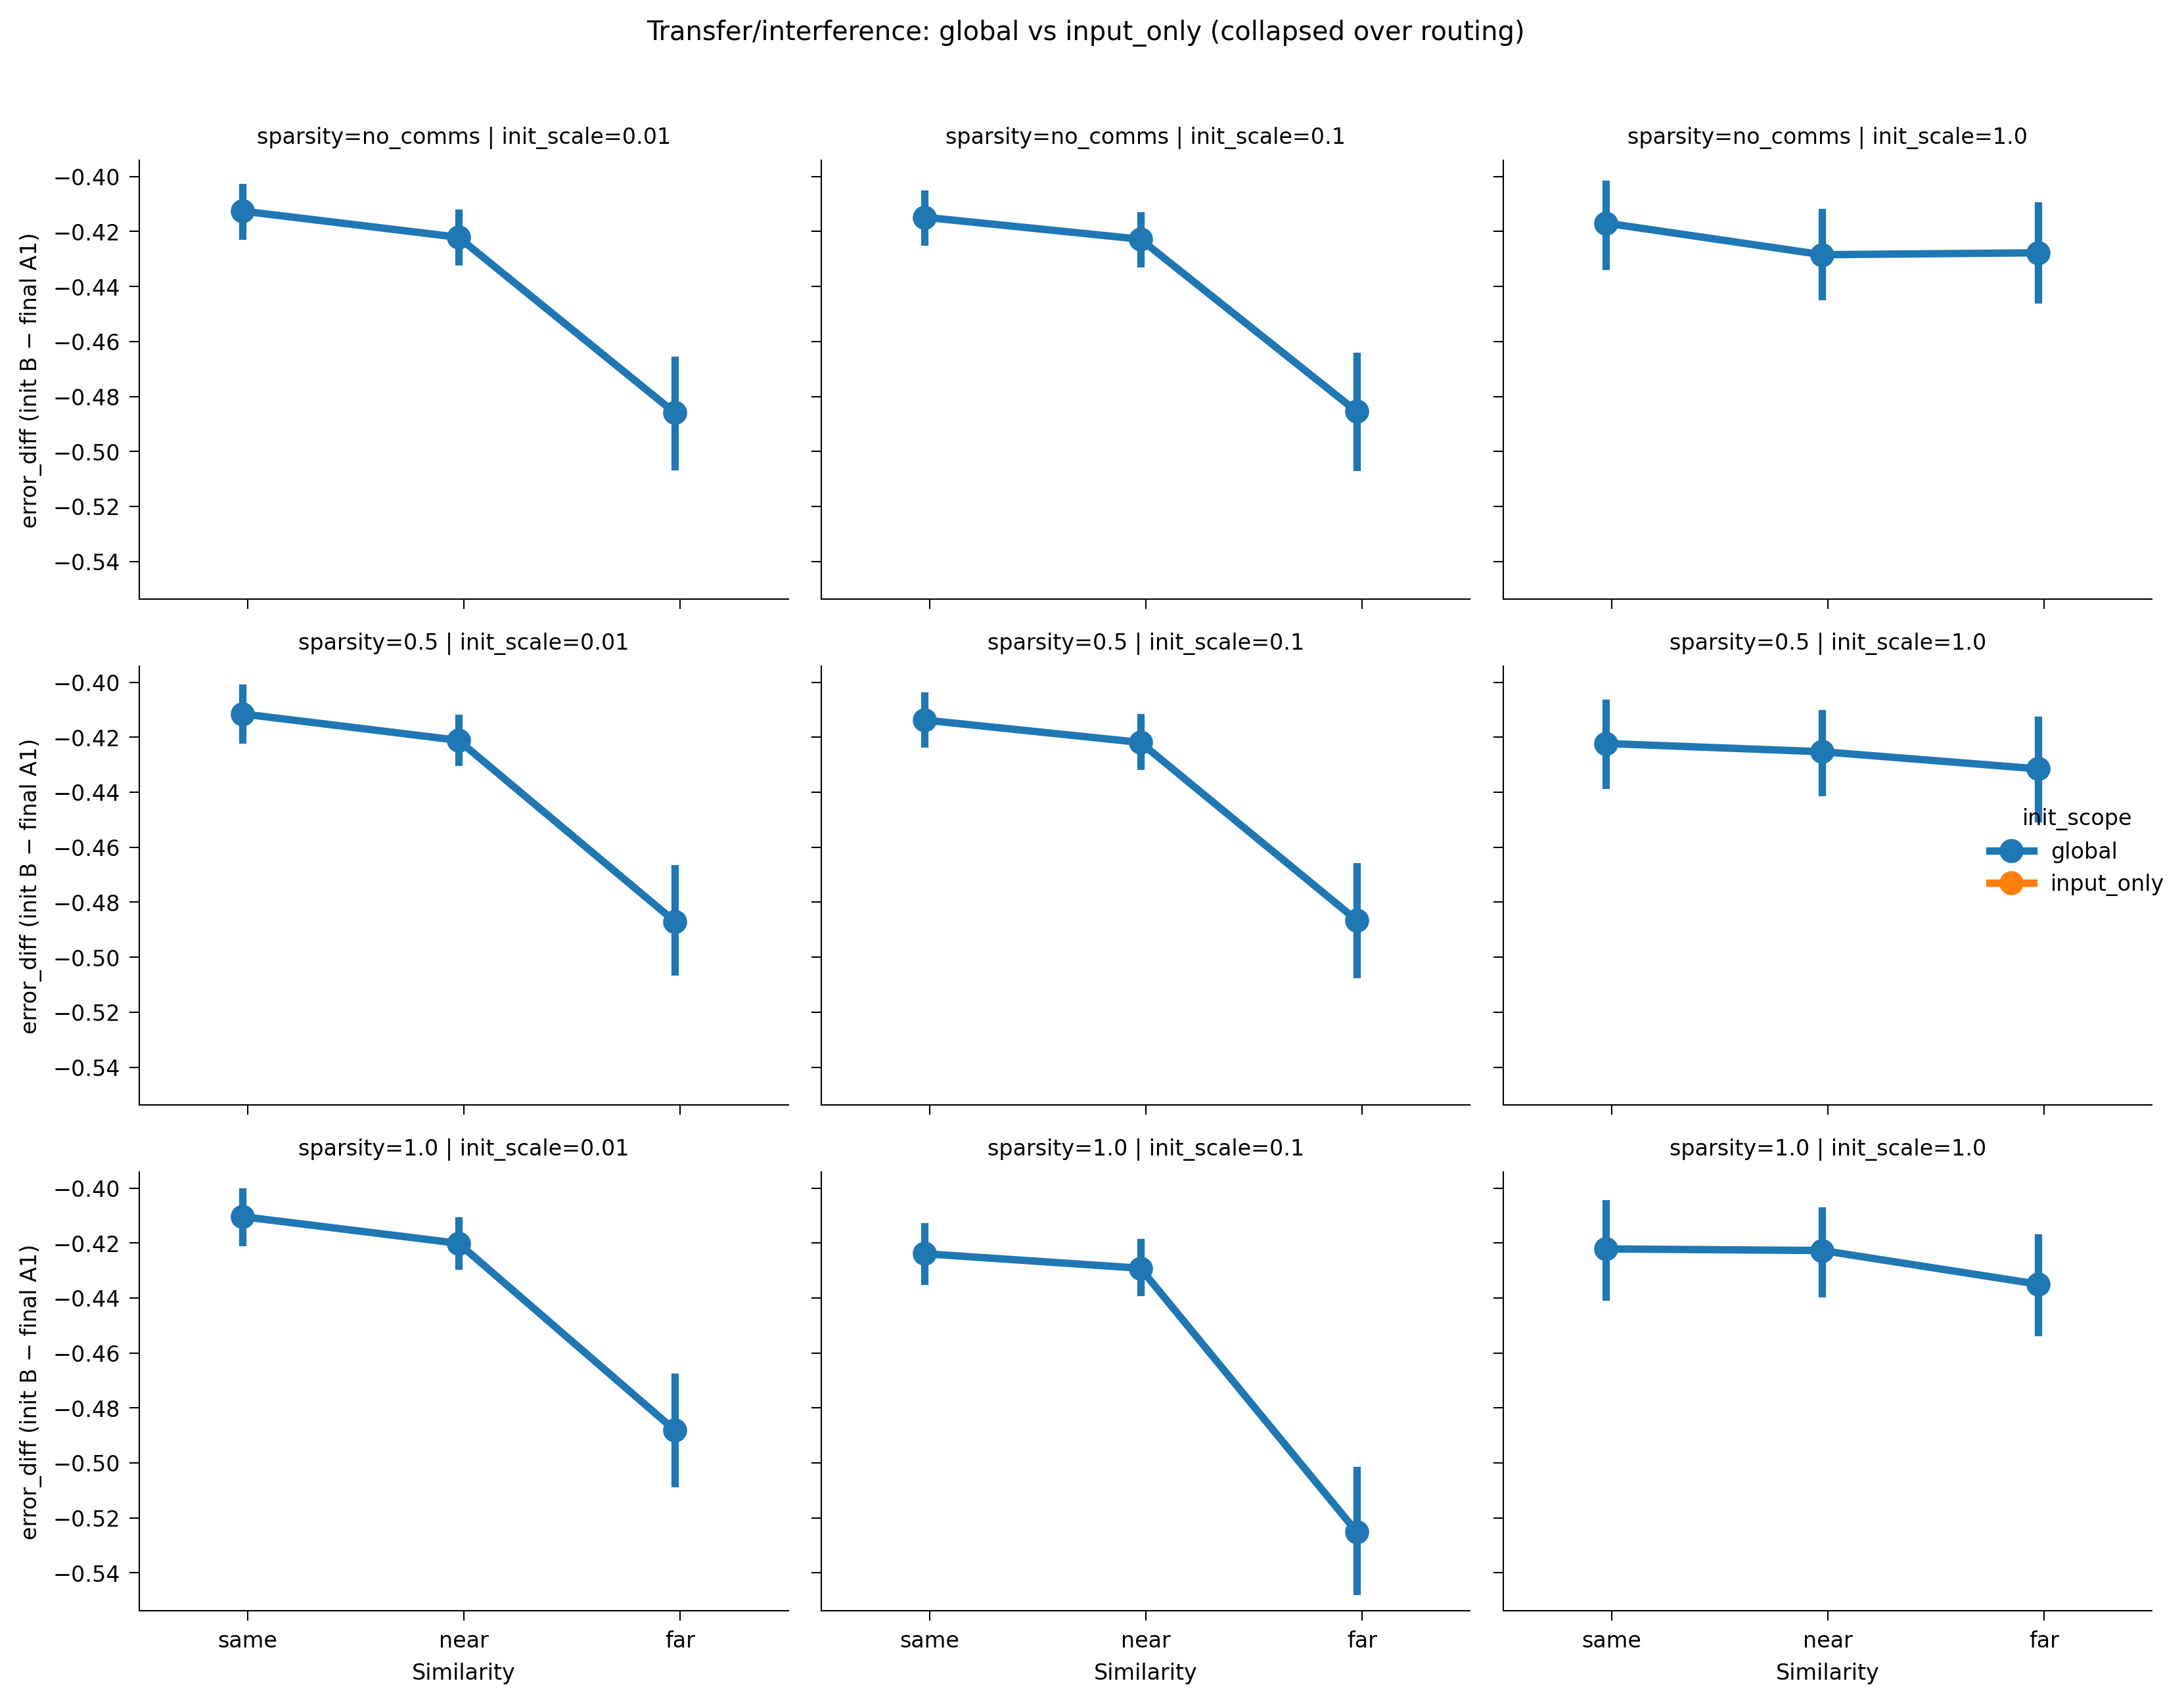

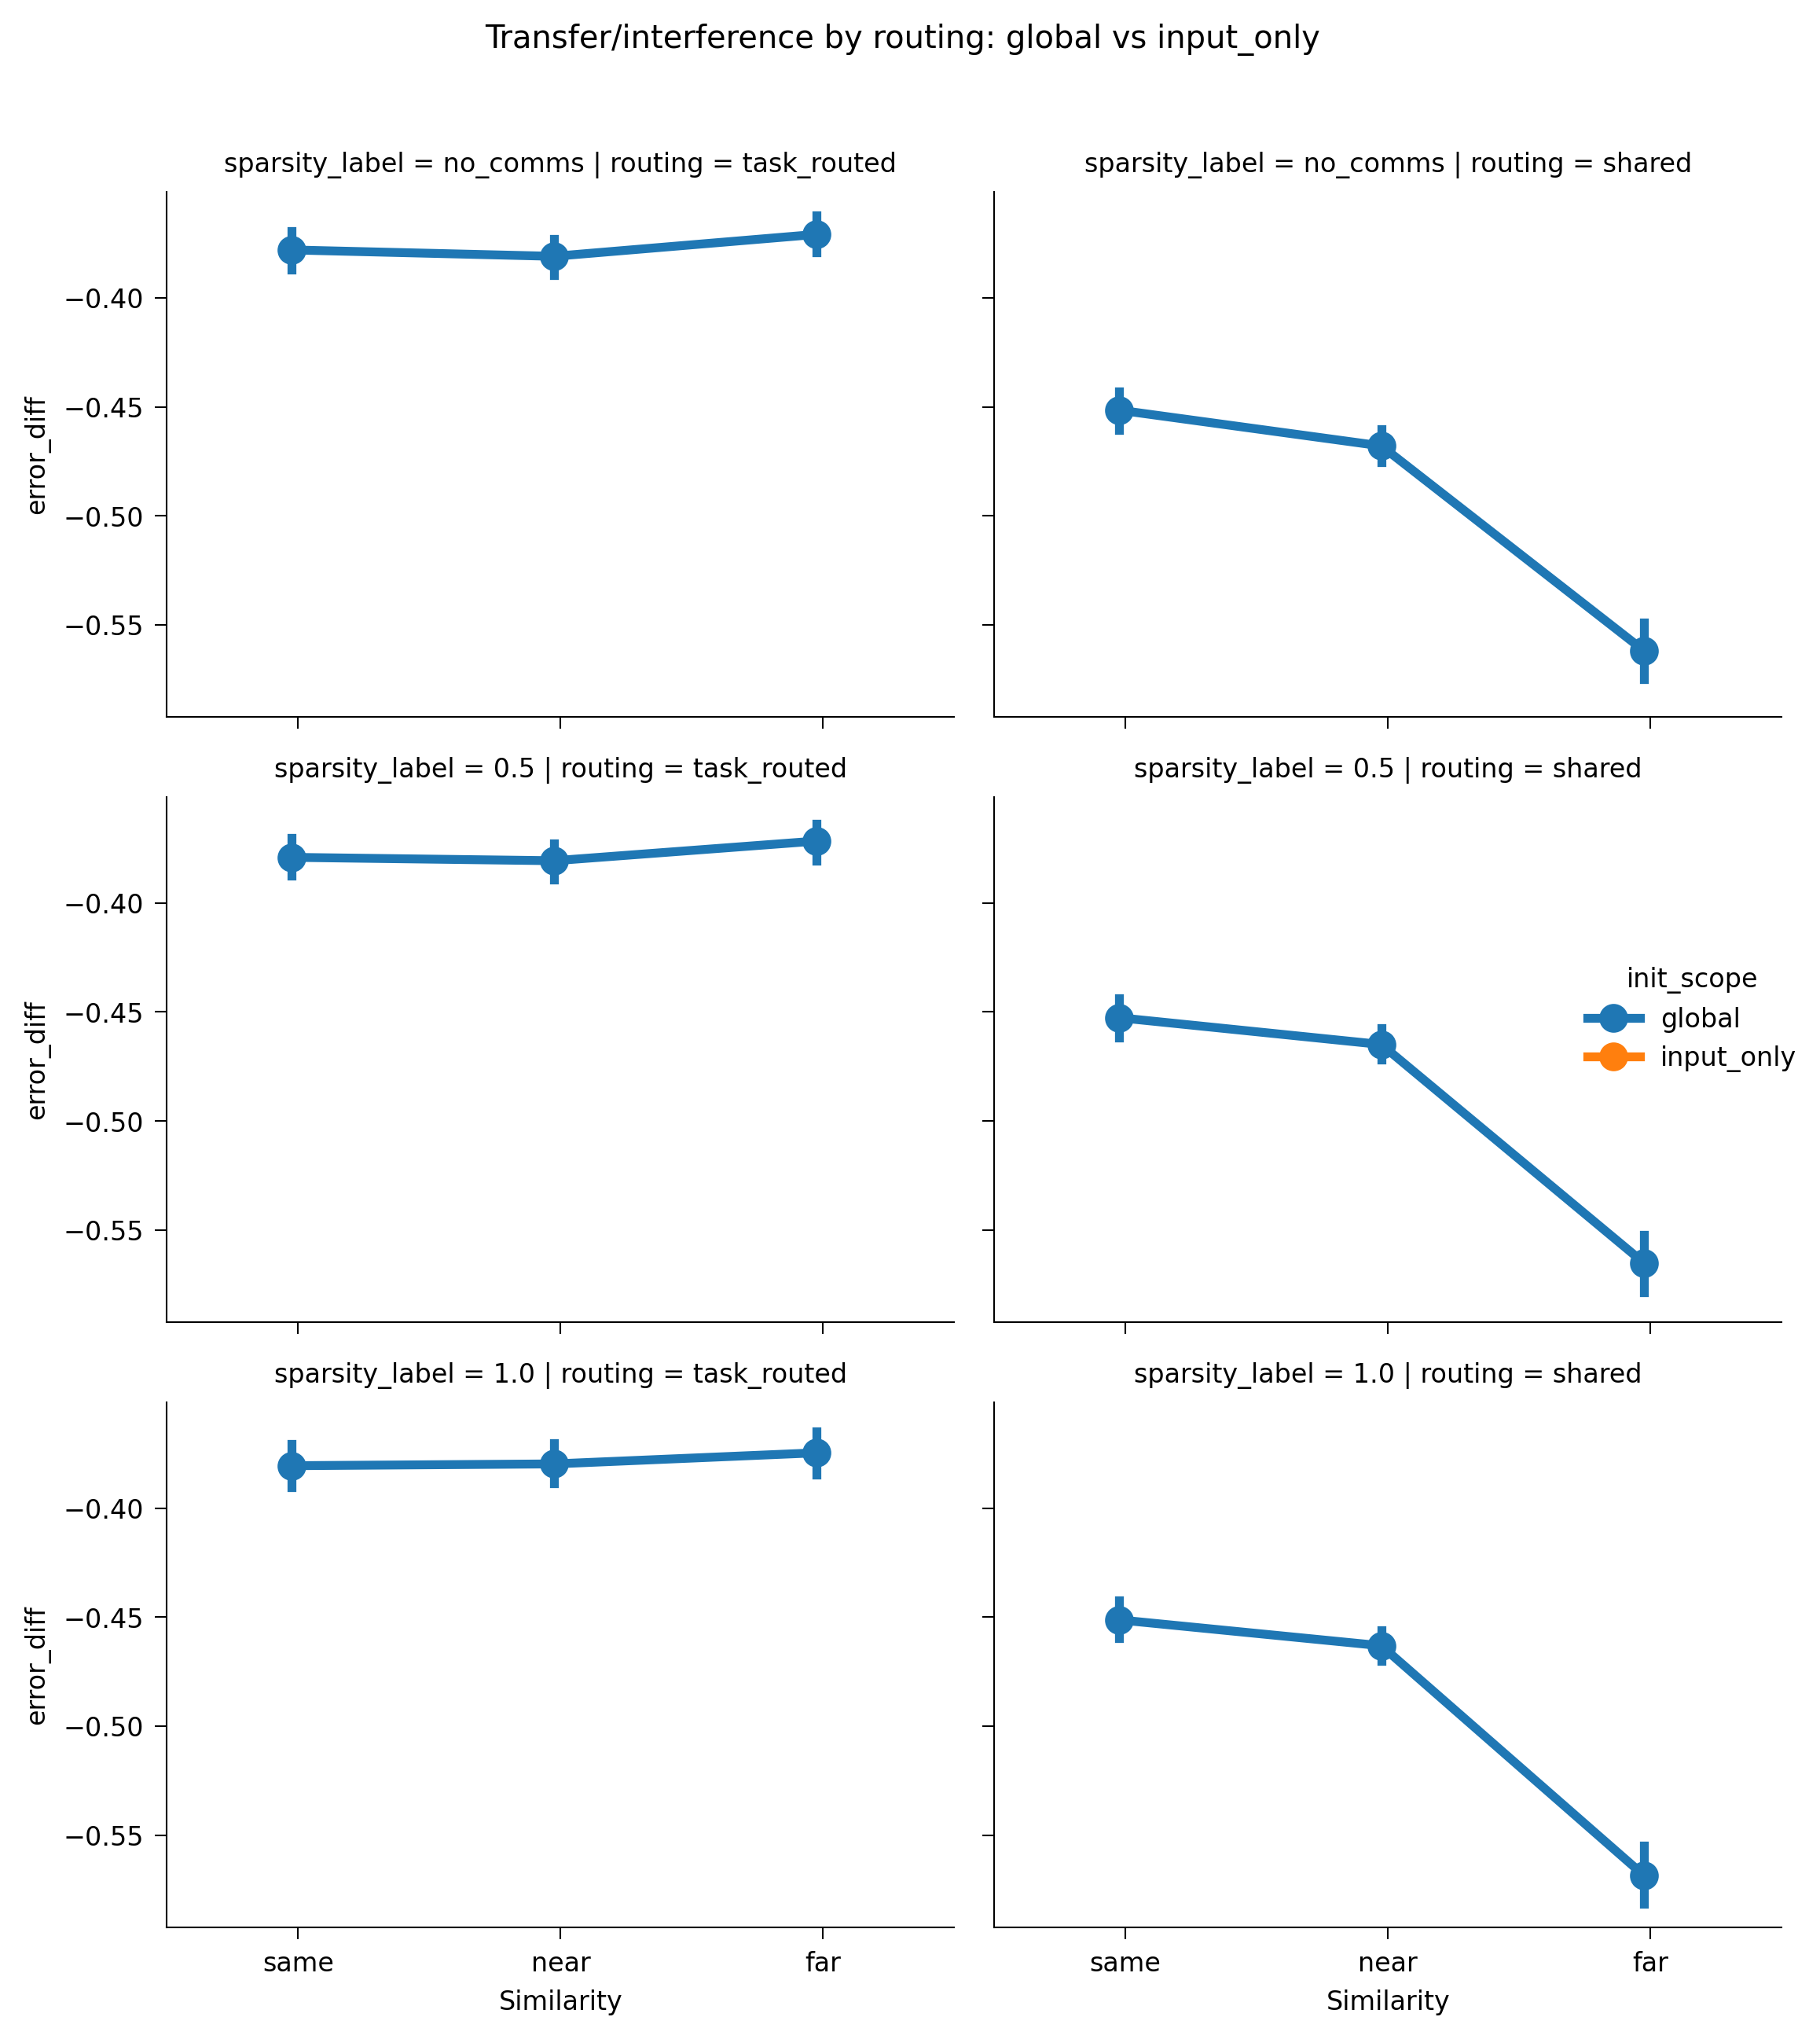

In [12]:
if not transfer_df.empty:
    g = sns.catplot(
        data=transfer_df,
        x="condition",
        y="error_diff",
        hue="init_scope",
        hue_order=PAPER_INIT_SCOPES,
        col="init_scale",
        col_order=PAPER_INIT_SCALES,
        row="sparsity_label",
        row_order=PAPER_SPARSITIES,
        kind="point",
        dodge=True,
        order=SIMILARITY_ORDER,
        height=2.8,
        aspect=1.2,
    )
    g.set_axis_labels("Similarity", "error_diff (init B − final A1)")
    g.set_titles(row_template="sparsity={row_name}", col_template="init_scale={col_name}")
    g.fig.suptitle("Transfer/interference: global vs input_only (collapsed over routing)", y=1.02)
    plt.tight_layout()
    plt.show()

    # same plot split by routing for cleaner read
    g = sns.catplot(
        data=transfer_df,
        x="condition",
        y="error_diff",
        hue="init_scope",
        hue_order=PAPER_INIT_SCOPES,
        col="routing",
        row="sparsity_label",
        col_order=PAPER_ROUTINGS,
        row_order=PAPER_SPARSITIES,
        kind="point",
        dodge=True,
        order=SIMILARITY_ORDER,
        height=2.8,
        aspect=1.2,
    )
    g.set_axis_labels("Similarity", "error_diff")
    g.fig.suptitle("Transfer/interference by routing: global vs input_only", y=1.02)
    plt.tight_layout()
    plt.show()
else:
    print("No transfer data.")


## Figure 2: Phase accuracy by init scope


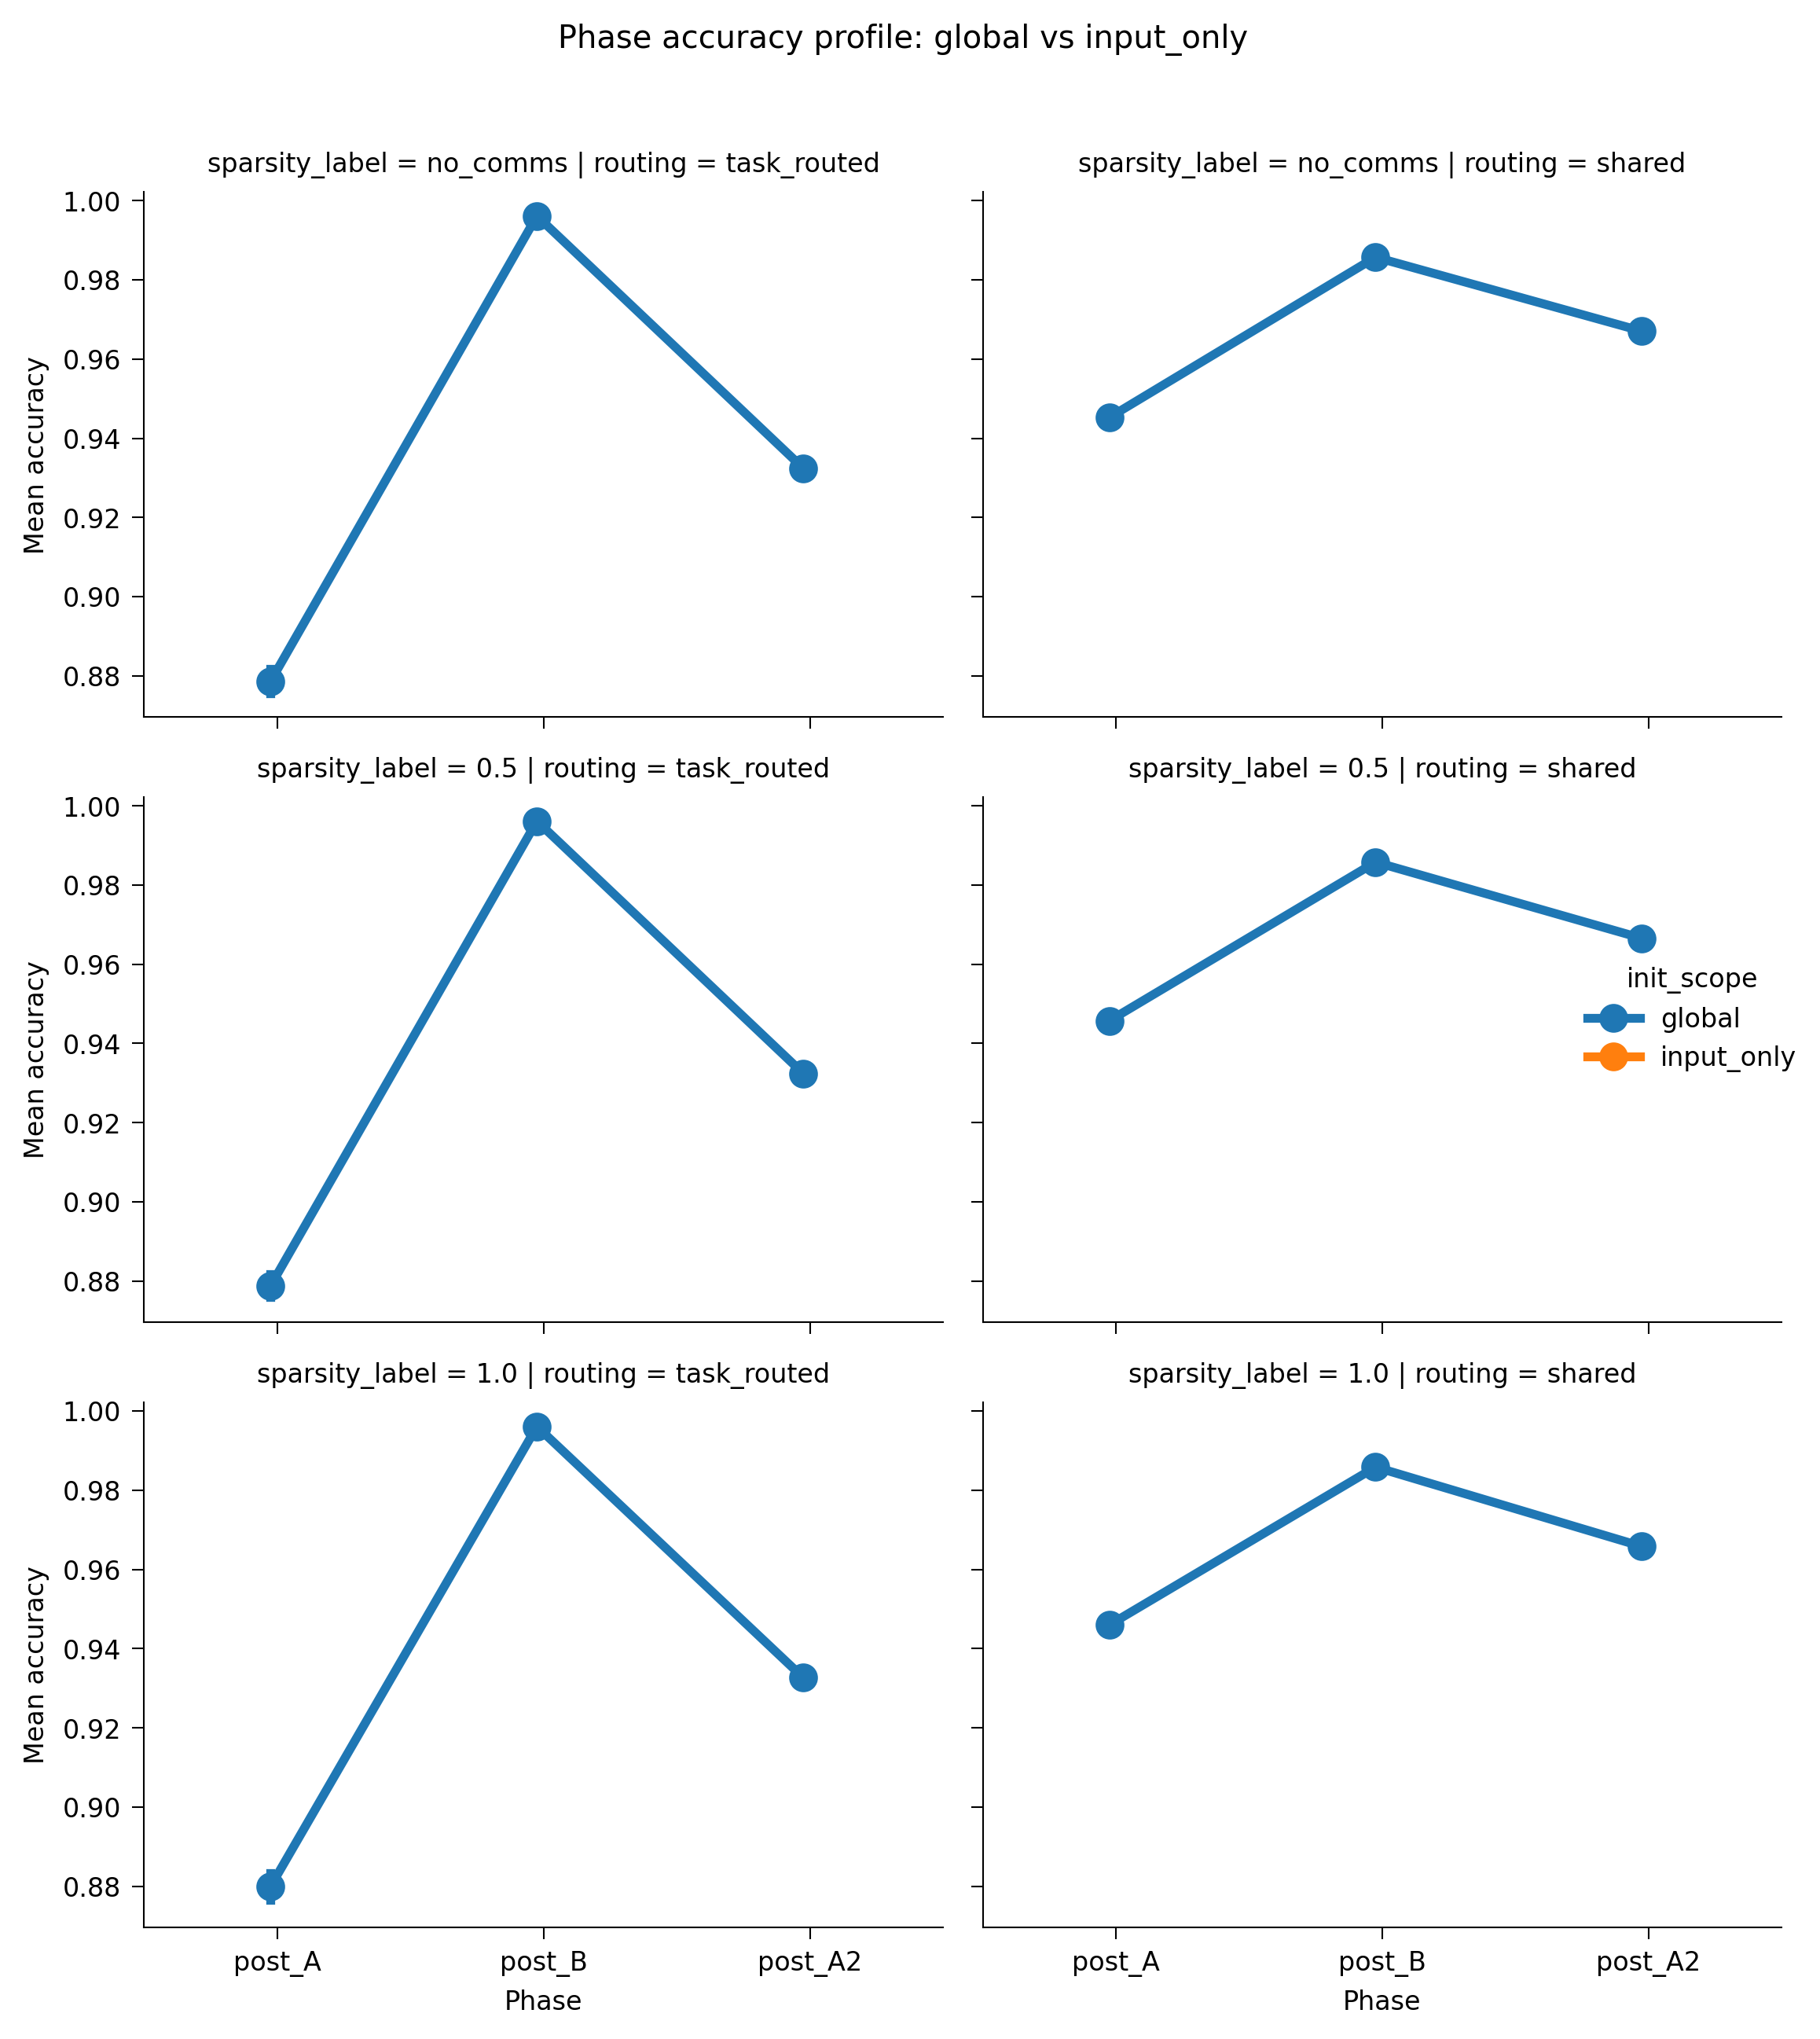

In [13]:
if not acc_df.empty:
    sub = acc_df.copy()
    g = sns.catplot(
        data=sub,
        x="phase",
        y="mean_accuracy",
        hue="init_scope",
        hue_order=PAPER_INIT_SCOPES,
        col="routing",
        row="sparsity_label",
        col_order=PAPER_ROUTINGS,
        row_order=PAPER_SPARSITIES,
        kind="point",
        dodge=True,
        order=PHASE_ORDER,
        height=2.8,
        aspect=1.2,
    )
    g.set_axis_labels("Phase", "Mean accuracy")
    g.fig.suptitle("Phase accuracy profile: global vs input_only", y=1.02)
    plt.tight_layout()
    plt.show()
else:
    print("No accuracy data.")


## Figure 3: Across-task principal angles (A vs B at post_B)


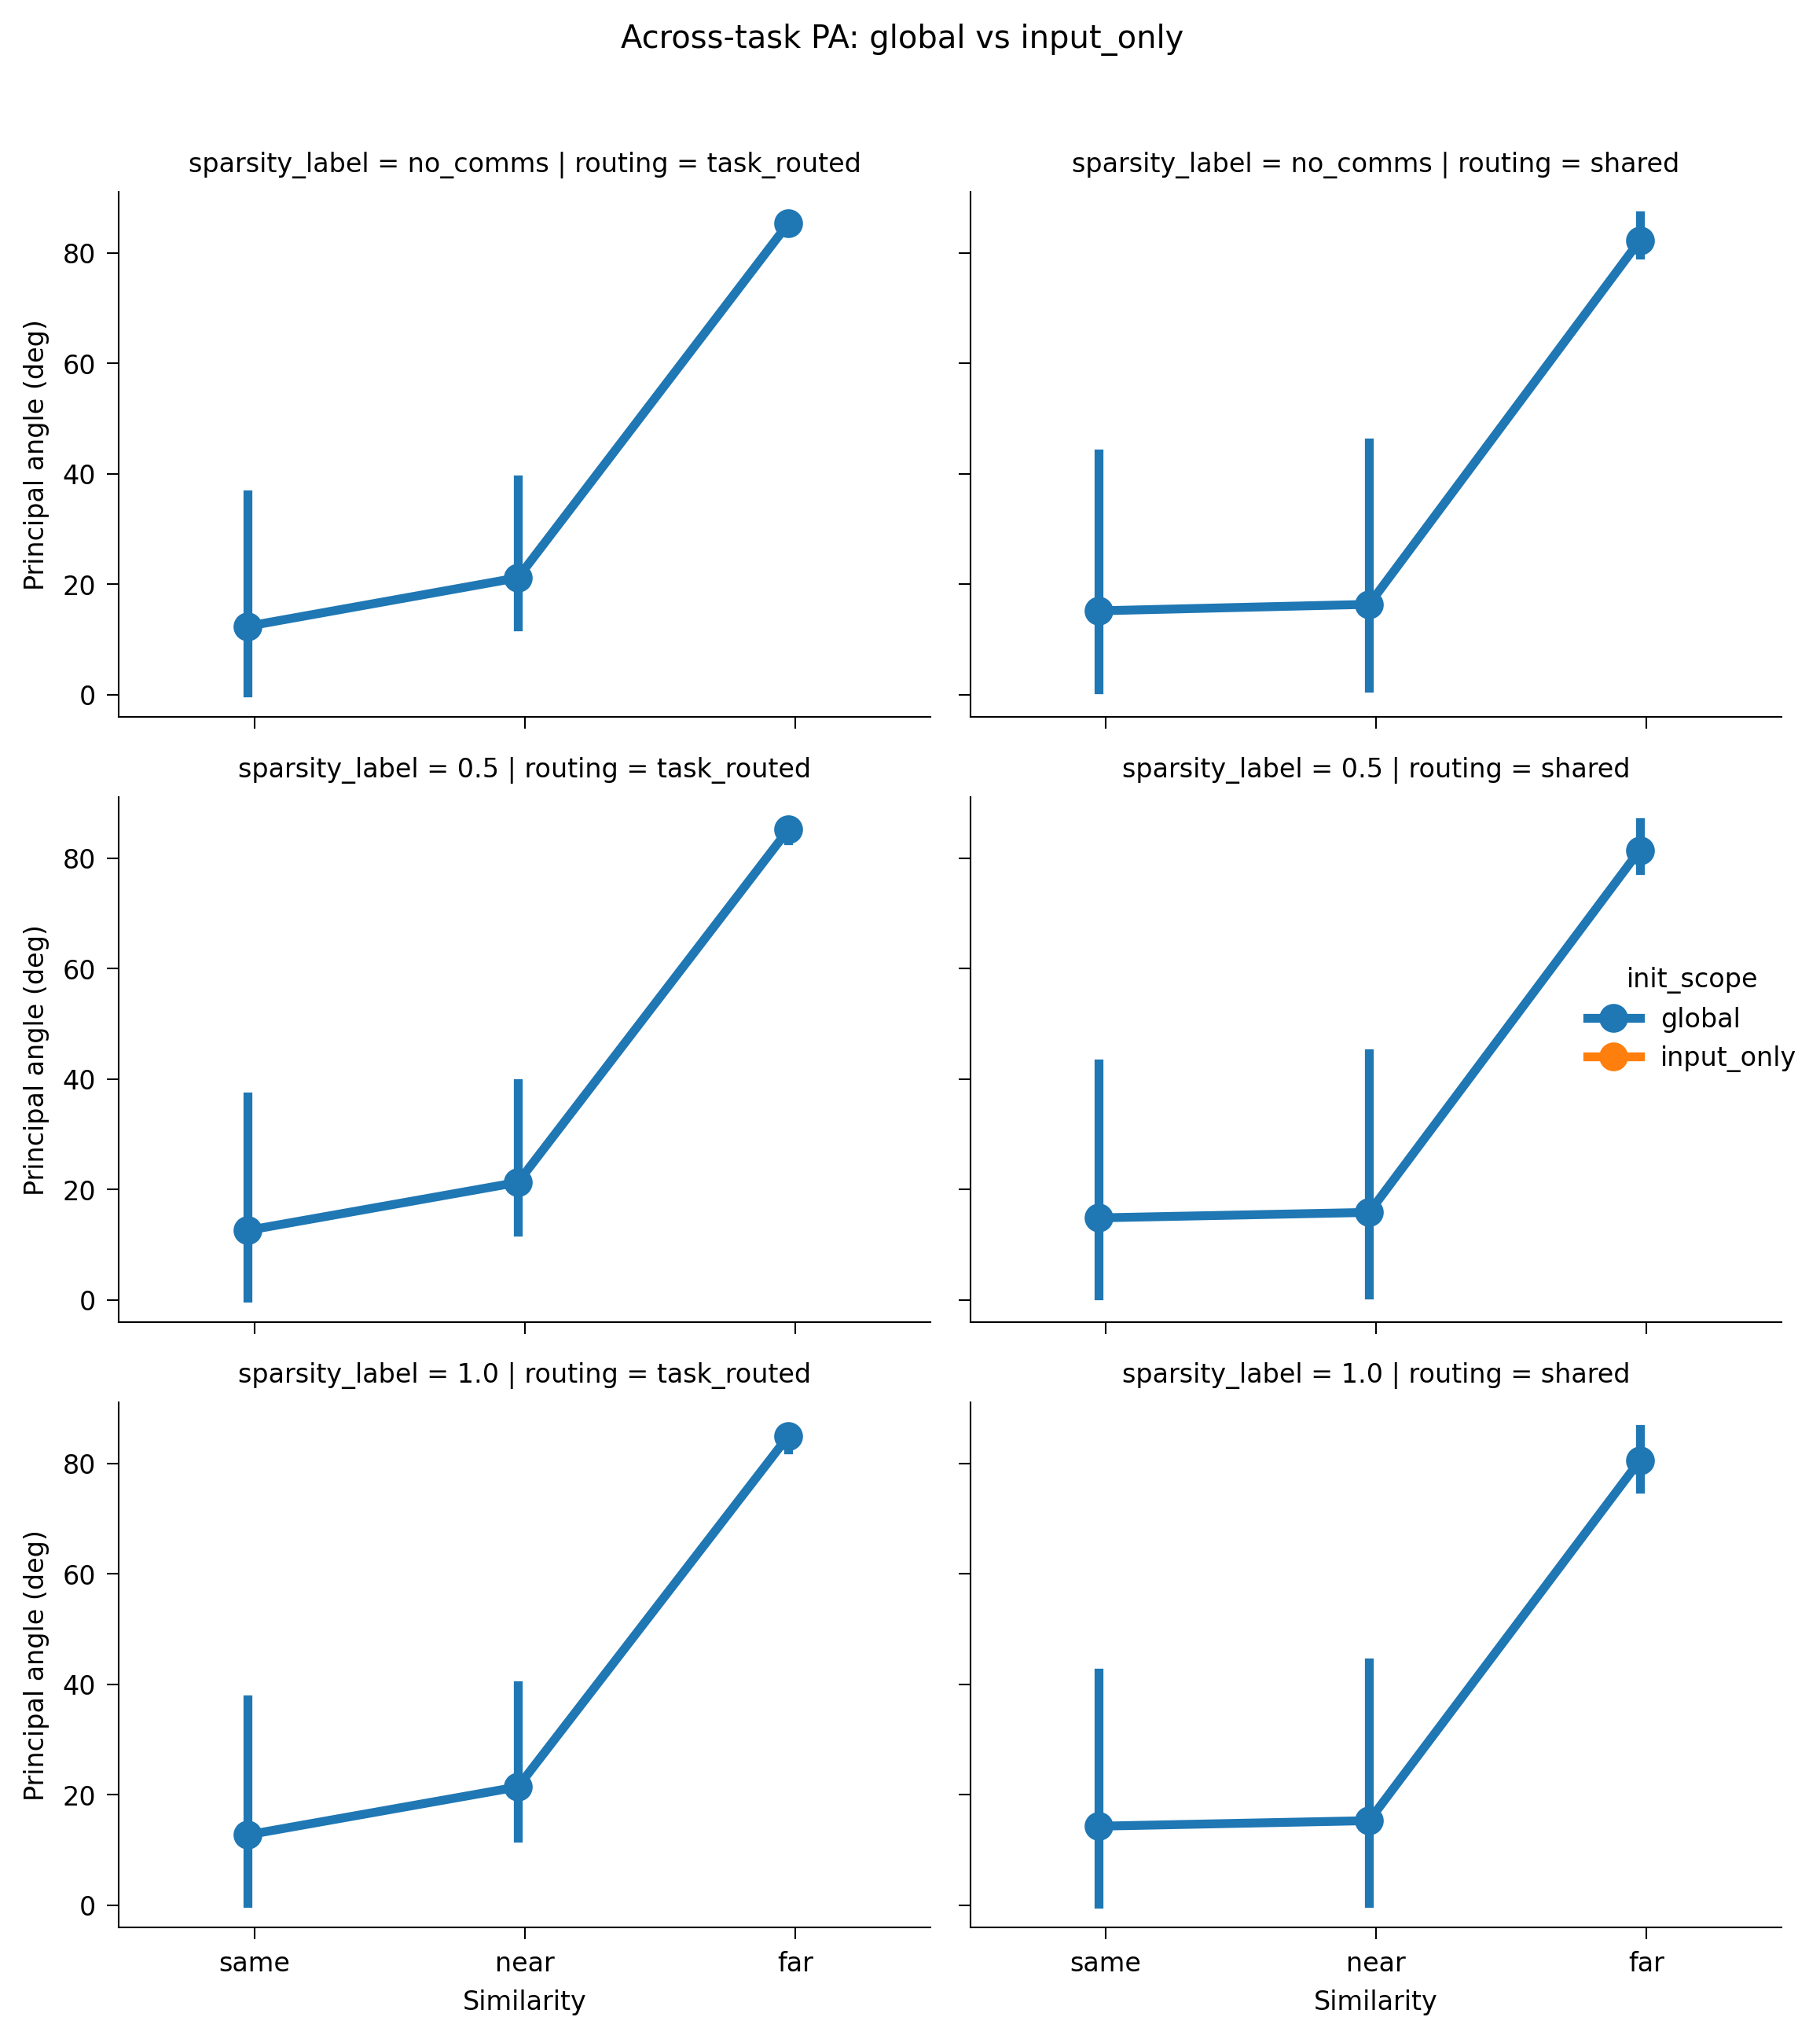

In [14]:
if not angles_df.empty:
    agg = (
        angles_df.groupby(["routing", "init_scope", "sparsity_label", "init_scale", "condition"], as_index=False)["principal_angle_between"]
        .mean()
        .rename(columns={"principal_angle_between": "angle_mean"})
    )

    g = sns.catplot(
        data=agg,
        x="condition",
        y="angle_mean",
        hue="init_scope",
        hue_order=PAPER_INIT_SCOPES,
        col="routing",
        row="sparsity_label",
        col_order=PAPER_ROUTINGS,
        row_order=PAPER_SPARSITIES,
        kind="point",
        dodge=True,
        order=SIMILARITY_ORDER,
        height=2.8,
        aspect=1.2,
    )
    g.set_axis_labels("Similarity", "Principal angle (deg)")
    g.fig.suptitle("Across-task PA: global vs input_only", y=1.02)
    plt.tight_layout()
    plt.show()
else:
    print("No principal-angle data.")


## Figure 4: PC count (99% variance), combined pathway


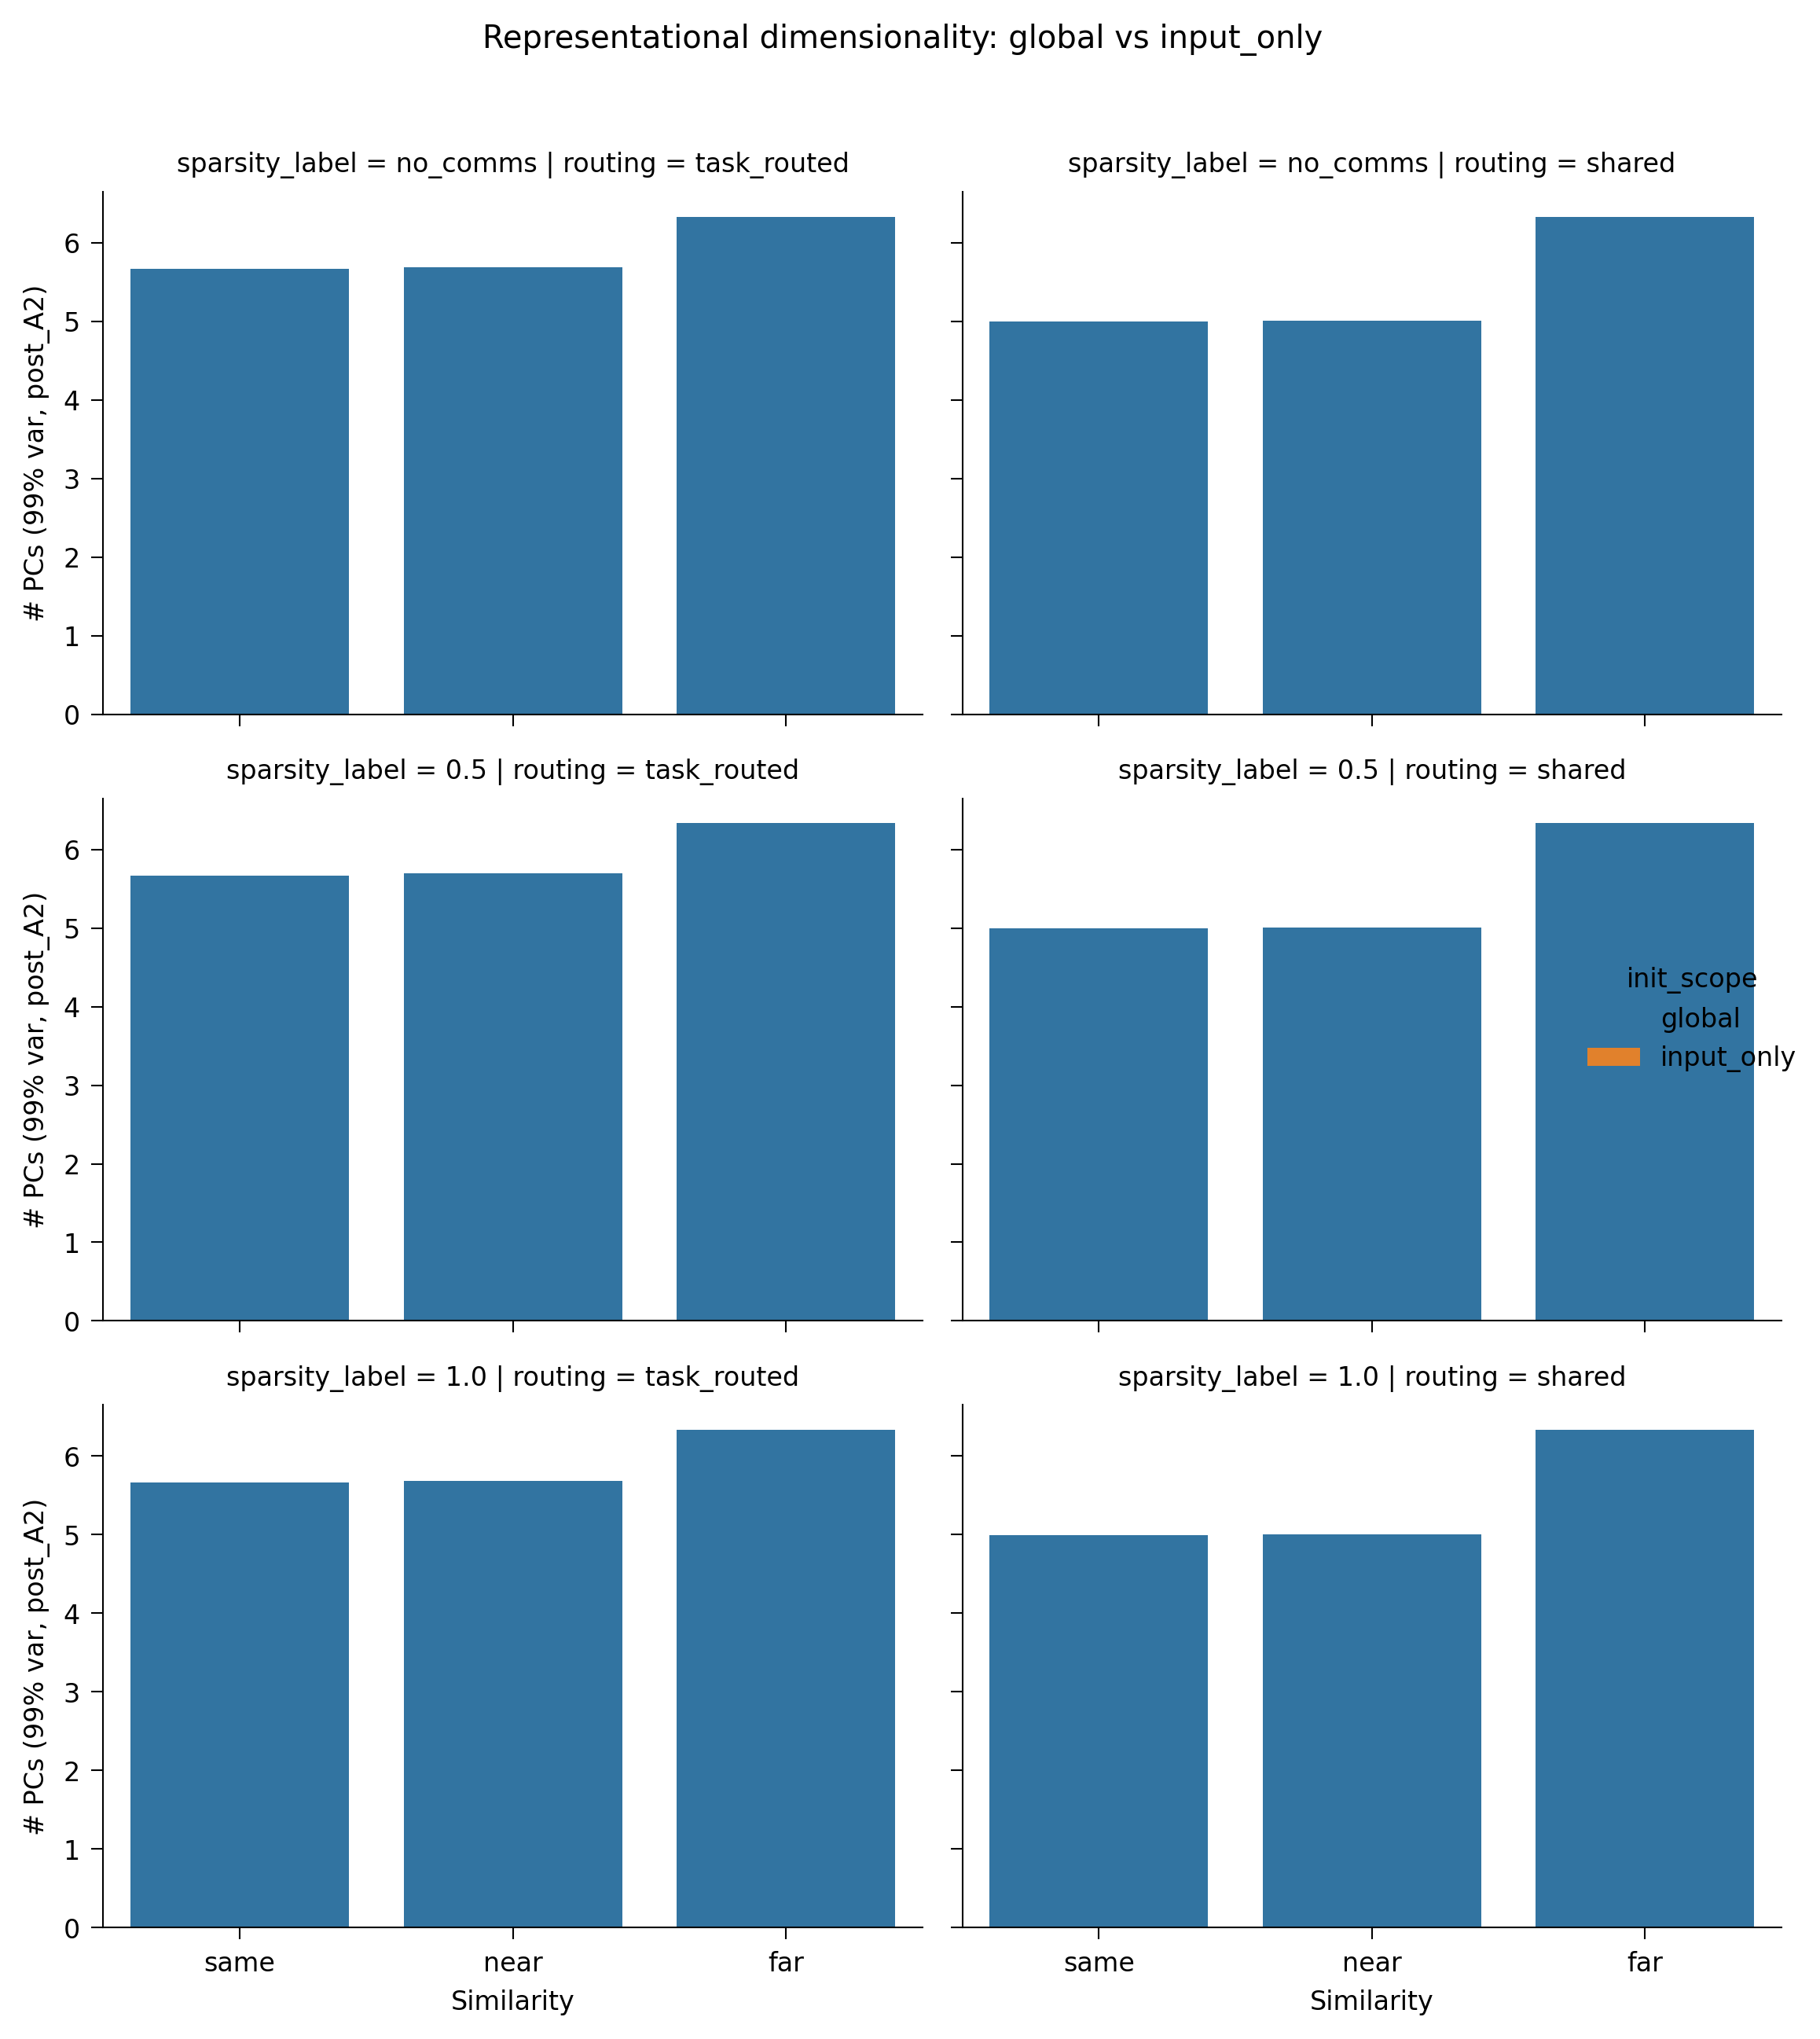

In [15]:
if not rep_df.empty and "n_pcs_99" in rep_df.columns:
    sub = rep_df[(rep_df["pathway"] == "combined")].copy()
    agg = (
        sub.groupby(["routing", "init_scope", "sparsity_label", "init_scale", "condition", "phase"], as_index=False)["n_pcs_99"]
        .mean()
    )

    # focus on post_A2 first (most interpretable for retention/interference)
    post = agg[agg["phase"] == "post_A2"].copy()
    g = sns.catplot(
        data=post,
        x="condition",
        y="n_pcs_99",
        hue="init_scope",
        hue_order=PAPER_INIT_SCOPES,
        col="routing",
        row="sparsity_label",
        col_order=PAPER_ROUTINGS,
        row_order=PAPER_SPARSITIES,
        kind="bar",
        order=SIMILARITY_ORDER,
        height=2.8,
        aspect=1.2,
        errorbar=None,
    )
    g.set_axis_labels("Similarity", "# PCs (99% var, post_A2)")
    g.fig.suptitle("Representational dimensionality: global vs input_only", y=1.02)
    plt.tight_layout()
    plt.show()
else:
    print("No representation data.")


## Appendix: quick availability table (what actually exists on disk)


In [16]:
avail = runs_df.copy()
if not avail.empty:
    avail_summary = (
        avail.groupby(["routing", "init_scope", "sparsity_label", "init_scale"], as_index=False)["path_exists"]
        .sum()
        .rename(columns={"path_exists": "n_folders"})
    )
    display(avail_summary)
else:
    print("No selected runs.")


/tmp/ipykernel_1007569/2568727486.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avail.groupby(["routing", "init_scope", "sparsity_label", "init_scale"], as_index=False)["path_exists"]


,routing,init_scope,sparsity_label,init_scale,n_folders
0,task_routed,global,no_comms,0.01,1
1,task_routed,global,no_comms,0.10,1
2,task_routed,global,no_comms,1.00,1
3,task_routed,global,0.5,0.01,1
4,task_routed,global,0.5,0.10,1
5,task_routed,global,0.5,1.00,1
6,task_routed,global,1.0,0.01,1
7,task_routed,global,1.0,0.10,1
8,task_routed,global,1.0,1.00,1
9,task_routed,input_only,no_comms,0.01,0
